In [1]:
!nvidia-smi

Tue Nov 18 19:26:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import libraries

In [2]:
!git clone https://github.com/VuTrinhNguyenHoang/eX-LAViTs.git

Cloning into 'eX-LAViTs'...
remote: Enumerating objects: 432, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 432 (delta 47), reused 53 (delta 24), pack-reused 351 (from 1)
Receiving objects: 100% (432/432), 171.19 KiB | 6.11 MiB/s, done.
Resolving deltas: 100% (275/275), done.


In [3]:
%cd eX-LAViTs
!ls -l

/kaggle/working/eX-LAViTs
total 28
drwxr-xr-x 2 root root 4096 Nov 18 19:26 configs
drwxr-xr-x 2 root root 4096 Nov 18 19:26 datasets
drwxr-xr-x 2 root root 4096 Nov 18 19:26 notebooks
-rw-r--r-- 1 root root  315 Nov 18 19:26 README.md
-rw-r--r-- 1 root root   93 Nov 18 19:26 requirements.txt
drwxr-xr-x 4 root root 4096 Nov 18 19:26 src
drwxr-xr-x 2 root root 4096 Nov 18 19:26 tests


In [4]:
# Repository
from src.models.linear_vit import create_linear_attention_vit
from src.models.explainability import ViTGradCAM, IntegratedGradient, Rollout, LAGRA
from src.utils.training import (
    create_run_directory, setup_logging, get_optimizer, get_scheduler,
    train_model, count_parameters, load_checkpoint
)
from src.pretrained import freeze_all_except_last_k_blocks, unfreeze_all
from src.utils.metrics import compute_loss_and_accuracy, compute_classification_metrics, evaluate_xai_method_dataset, evaluate_class_specificity_cosine
from src.utils.visualization import save_all_plots, create_training_summary_plot
from src.explain import visualize_methods

# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.transforms.autoaugment import AutoAugment, AutoAugmentPolicy
import timm
from sklearn.model_selection import train_test_split

from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import math
from tqdm.auto import tqdm
import os

## Config

In [5]:
run_name = "run001"

LR = 2e-4
WD = 1e-3

EPOCHS = 50
warmup_epochs = 10
remaining_epochs = EPOCHS - warmup_epochs

PATIENCE = 5

BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
print(NUM_WORKERS, DEVICE)

4 cuda


## Datasets

In [6]:
# Load csv data
data_dir = Path("/kaggle/input/cat-dog-images-for-classification")
data_csv = data_dir / "cat_dog.csv"
data_img = data_dir / "cat_dog"

df = pd.read_csv(data_csv)
df["image"] = data_img / df["image"]
df.head()

,image,labels
0,/kaggle/input/cat-dog-images-for-classificatio...,1
1,/kaggle/input/cat-dog-images-for-classificatio...,0
2,/kaggle/input/cat-dog-images-for-classificatio...,0
3,/kaggle/input/cat-dog-images-for-classificatio...,0
4,/kaggle/input/cat-dog-images-for-classificatio...,1


In [7]:
df["labels"].value_counts(True)

labels
1    0.5
0    0.5
Name: proportion, dtype: float64

In [8]:
# Split train/valid/test
train_df, tmp_df = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["labels"])
valid_df, test_df = train_test_split(tmp_df, test_size=0.5, random_state=SEED, stratify=tmp_df["labels"])

train_df.shape, valid_df.shape, test_df.shape

((17500, 2), (3750, 2), (3750, 2))

### Create Dataset

In [9]:
class DS(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rows = self.df.iloc[idx]
        path, y = rows["image"], rows["labels"]
        img = Image.open(path).convert("RGB")

        return self.transform(img), y

In [10]:
# Transform
train_transform = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

test_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [11]:
n_classes = len(df["labels"].unique())

train_dataset = DS(train_df, train_transform)
valid_dataset = DS(valid_df, test_transform)
test_dataset = DS(test_df, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

len(train_loader), len(valid_loader), len(test_loader)

(274, 59, 59)

In [12]:
batch_test = next(iter(train_loader))
batch_test[0].shape, batch_test[1].shape

(torch.Size([64, 3, 224, 224]), torch.Size([64]))

## Train model

In [13]:
# model_name = "vit_tiny_patch16_224"

# model = create_linear_attention_vit(
#     model_name,
#     pretrained=True,
#     num_classes=n_classes,
#     drop_path_rate=0.1,
#     attn_drop_rate=0.1,
#     proj_drop_rate=0.1,
# )

In [14]:
# run_dir = create_run_directory("experiments", run_name)
# print(f"Created run directory: {run_dir}")

# logger = setup_logging(os.path.join(run_dir, 'logs'))
# logger.info(f"Starting training with {run_name}")
# logger.info(f"Using device: {DEVICE}")

# logger.info(f"Train batches: {len(train_loader)}")
# logger.info(f"Validation batches: {len(valid_loader)}")
# logger.info(f"Test batches: {len(test_loader)}")

# model = model.to(DEVICE)
# total_params, trainable_params = count_parameters(model)
# logger.info(f"Model loaded with {total_params:,} total parameters ({trainable_params:,} trainable)")

# criterion = nn.CrossEntropyLoss()
# logger.info("Starting training...")

In [15]:
# if warmup_epochs > 0:
#     logger.info(f"Phase 1: Warm-up last 2 blocks for {warmup_epochs} epochs")
#     freeze_all_except_last_k_blocks(model, k=2, logger=logger)
#     optimizer1 = get_optimizer(
#         model,
#         optimizer_name="adamw",
#         learning_rate=LR * 0.5,
#         weight_decay=WD,
#     )
#     scheduler1 = get_scheduler(
#         optimizer1, 
#         "cosine", 
#         **{
#             "T_max": warmup_epochs,
#             "eta_min": 0
#         }
#     )

#     metrics_phase1 = train_model(
#         model=model,
#         train_loader=train_loader,
#         val_loader=valid_loader,
#         criterion=criterion,
#         optimizer=optimizer1,
#         scheduler=scheduler1,
#         device=DEVICE,
#         num_epochs=warmup_epochs,
#         run_dir=run_dir,
#         save_freq=50,
#         print_freq=50,
#         early_stopping_patience=PATIENCE,
#         logger=logger
#     )
#     logger.info("Phase 1 completed.")

In [16]:
# if remaining_epochs > 0:
#     logger.info(f"Phase 2: Unfreeze last 4 blocks and finetune for {remaining_epochs} epochs")
#     freeze_all_except_last_k_blocks(model, k=4, logger=logger)
#     optimizer2 = get_optimizer(
#         model,
#         optimizer_name="adamw",
#         learning_rate=LR,
#         weight_decay=WD,
#     )
#     scheduler2 = get_scheduler(
#         optimizer2, 
#         "cosine", 
#         **{
#             "T_max": remaining_epochs,
#             "eta_min": 0
#         }
#     )

#     metrics_phase2 = train_model(
#         model=model,
#         train_loader=train_loader,
#         val_loader=valid_loader,
#         criterion=criterion,
#         optimizer=optimizer2,
#         scheduler=scheduler2,
#         device=DEVICE,
#         num_epochs=remaining_epochs,
#         run_dir=run_dir,
#         save_freq=50,
#         print_freq=50,
#         early_stopping_patience=PATIENCE,
#         logger=logger
#     )
#     logger.info("Phase 2 completed.")

## Evaluate

In [17]:
# logger.info("Training completed!")

# # Evaluate on test setlogger.info("Evaluating on test set...")
# test_results = compute_loss_and_accuracy(
#     model, test_loader, criterion, DEVICE, return_predictions=True
# )

# # Compute detailed classification metrics
# classification_metrics = compute_classification_metrics(
#     test_results['predictions'],
#     test_results['targets'],
#     return_confusion_matrix=True
# )

# # Log test results
# logger.info(f"Test Results:")
# logger.info(f"  Loss: {test_results['loss']:.4f}")
# logger.info(f"  Top-1 Accuracy: {test_results['top1_accuracy']:.2f}%")
# logger.info(f"  Macro F1-Score: {classification_metrics['macro_f1']:.2f}%")
# logger.info(f"  Weighted F1-Score: {classification_metrics['weighted_f1']:.2f}%")

In [18]:
# # Generate and save plots
# logger.info("Generating plots...")
# save_all_plots(
#     metrics_tracker=metrics_phase2,
#     run_dir=run_dir,
#     y_true=test_results['targets'],
#     y_pred=test_results['predictions'],
# )

# # Create comprehensive training summary plot
# model_info = {
#     'model_name': model_name,
#     'total_params': total_params,
# }

# summary_plot = create_training_summary_plot(metrics_phase2, model_info)
# summary_plot.savefig(
#     os.path.join(run_dir, 'plots', 'training_summary.png'),
#     bbox_inches='tight', dpi=300
# )

## Explain

In [19]:
model_name = "vit_tiny_patch16_224"
checkpoint_path = "/kaggle/input/ex-lavit/pytorch/default/2/linear_vit_tiny_dogcat.pth"

model = create_linear_attention_vit(
    model_name,
    pretrained=False,
    num_classes=n_classes
)

load_checkpoint(
    checkpoint_path,
    model,
    device=DEVICE
)

model.to(DEVICE).eval()

Creating Linear Attention ViT: vit_tiny_patch16_224
    Pretrained: False
    Classes: 2
    Image size: 224
    Original parameters: 5,524,802
Replacing attention layers with LinearMultiheadAttention...
    Kernel: elu
    Epsilon: 1e-06
   Block 0: dim=192, heads=3, mlp_ratio=4.0
   Block 1: dim=192, heads=3, mlp_ratio=4.0
   Block 2: dim=192, heads=3, mlp_ratio=4.0
   Block 3: dim=192, heads=3, mlp_ratio=4.0
   Block 4: dim=192, heads=3, mlp_ratio=4.0
   Block 5: dim=192, heads=3, mlp_ratio=4.0
   Block 6: dim=192, heads=3, mlp_ratio=4.0
   Block 7: dim=192, heads=3, mlp_ratio=4.0
   Block 8: dim=192, heads=3, mlp_ratio=4.0
   Block 9: dim=192, heads=3, mlp_ratio=4.0
   Block 10: dim=192, heads=3, mlp_ratio=4.0
   Block 11: dim=192, heads=3, mlp_ratio=4.0
Successfully replaced 12 attention blocks
    Total parameters: 5,524,802
    Trainable parameters: 5,524,802


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): LinearAttentionBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): LinearMultiheadAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (out_proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (fc2): Linear(in_features=768, out_features=192, bias=True)
       

In [20]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

### LAGRA

In [21]:
idx = np.random.randint(len(test_dataset))

x, y_true = test_dataset[idx] # test sample
xb = x.unsqueeze(0).to(DEVICE)

In [22]:
proposal_model = LAGRA(model, has_cls=True, blocks_attr="blocks")

out = proposal_model.attribute(xb, use_logits=True)

In [23]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.0641, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.0609, device='cuda:0', grad_fn=<MeanBackward0>))

### GradCAM

In [24]:
gradcam_model = ViTGradCAM(model, has_cls=True)

out = gradcam_model.attribute(xb)

In [25]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.8633, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.7909, device='cuda:0', grad_fn=<MeanBackward0>))

### Integrated Gradients

In [26]:
ig_model = IntegratedGradient(model, m_steps=32)

out = ig_model.attribute(xb)

In [27]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.0928, device='cuda:0'),
 tensor(0.0213, device='cuda:0'))

### Rollout

In [28]:
rollout_model = Rollout(model, has_cls=True)

out = rollout_model.attribute(xb)

In [29]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.1556, device='cuda:0'),
 tensor(0.1437, device='cuda:0'))

## Visualization

3507


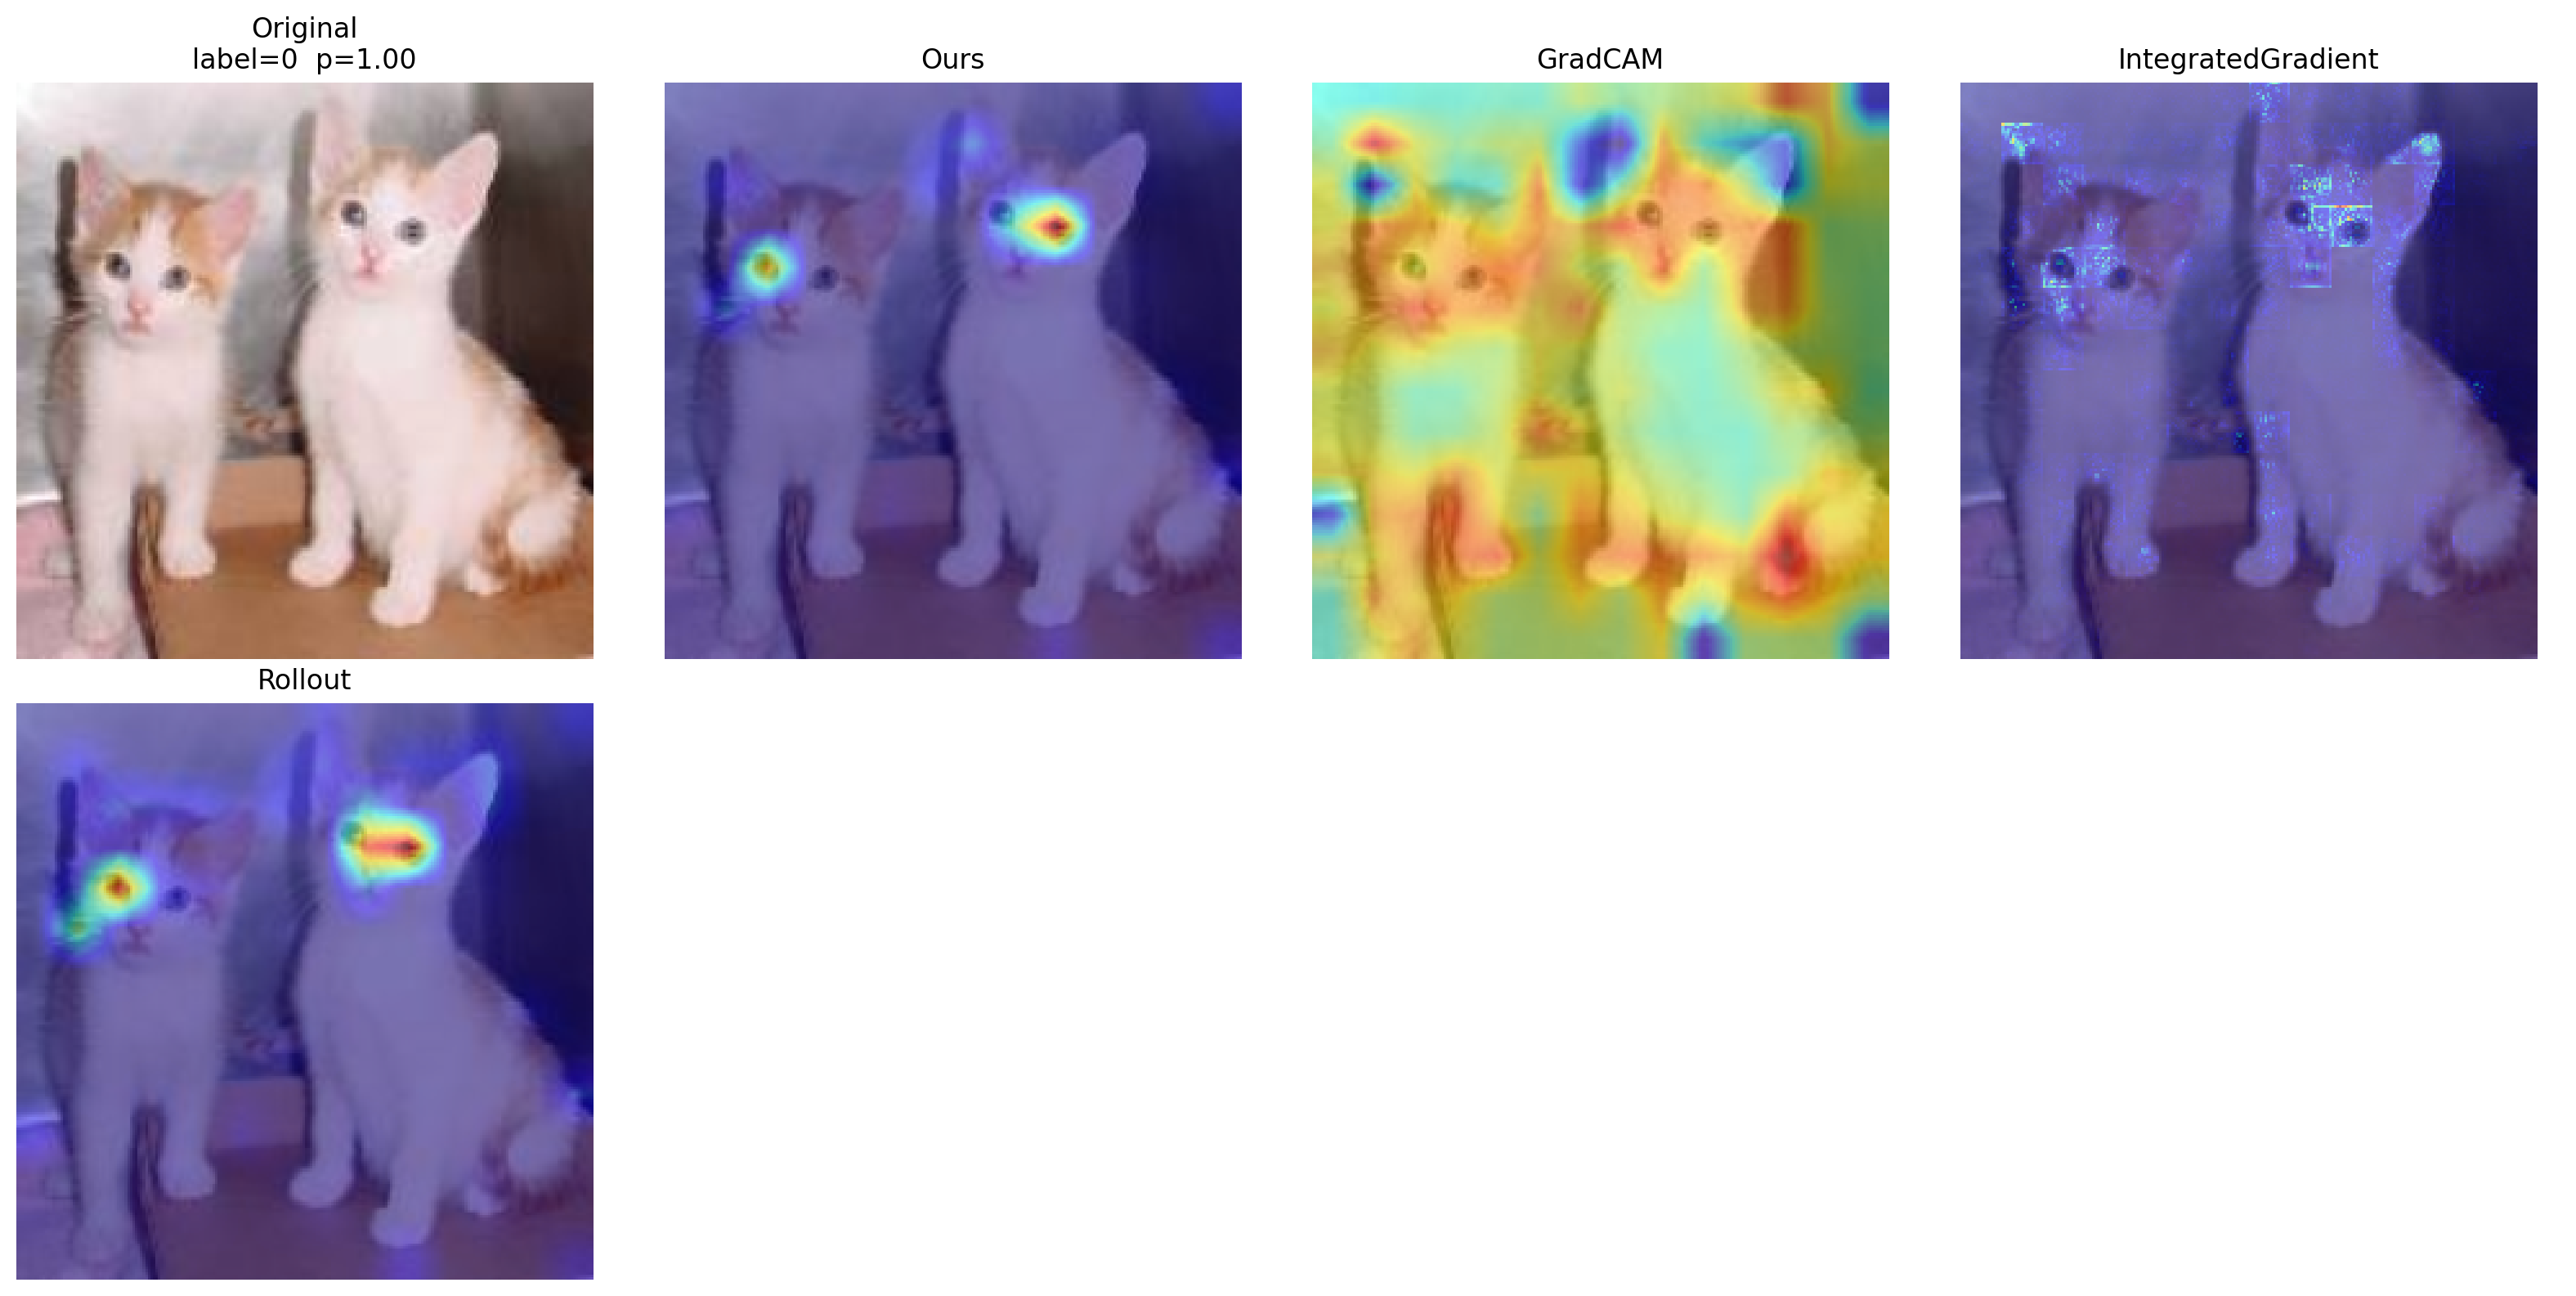

In [30]:
idx = np.random.randint(len(test_dataset))
print(idx)

_ = visualize_methods(
    test_dataset, idx,
    {
        "Ours": proposal_model,
        "GradCAM": gradcam_model,
        "IntegratedGradient": ig_model,
        "Rollout": rollout_model
    },
    use_pred=True,
    device=DEVICE,
)

## Evaluate Explain methods

In [31]:
methods = {
    "Ours": proposal_model,
    "GradCAM": gradcam_model,
    "IG": ig_model,
    "Rollout": rollout_model
}

results = {}
for name, attr in methods.items():
    print(f"Evaluating {name}...")
    stats_faith = evaluate_xai_method_dataset(
        attributor=attr,
        dataset=test_dataset,
        device=DEVICE,
        use_pred=True,
        max_samples=None,
        steps=20,
        baseline=None,
        use_logits=True,
        verbose_every=50,
    )

    stats_cs = evaluate_class_specificity_cosine(
        attributor=attr,
        dataset=test_dataset,
        device=DEVICE,
        max_samples=None,
        use_logits=True,
        use_pred=True,
        verbose_every=50,
    )

    metrics = {
        **stats_faith,
        "cosine_cs_mean": stats_cs["cosine_cs_mean"],
        "cosine_cs_std": stats_cs["cosine_cs_std"],
    }
    results[name] = metrics
    print(f"Results for {name}: {metrics}")
    print("-" * 50)

Evaluating Ours...
[50/3750] AUC_del_mean=0.2444, AUC_ins_mean=0.7896, entropy_mean=0.8596
[100/3750] AUC_del_mean=0.2942, AUC_ins_mean=0.8088, entropy_mean=0.8672
[150/3750] AUC_del_mean=0.2969, AUC_ins_mean=0.8054, entropy_mean=0.8681
[200/3750] AUC_del_mean=0.3059, AUC_ins_mean=0.7939, entropy_mean=0.8709
[250/3750] AUC_del_mean=0.3039, AUC_ins_mean=0.7985, entropy_mean=0.8711
[300/3750] AUC_del_mean=0.2999, AUC_ins_mean=0.7845, entropy_mean=0.8705
[350/3750] AUC_del_mean=0.2998, AUC_ins_mean=0.7914, entropy_mean=0.8671
[400/3750] AUC_del_mean=0.2994, AUC_ins_mean=0.7932, entropy_mean=0.8679
[450/3750] AUC_del_mean=0.2951, AUC_ins_mean=0.7879, entropy_mean=0.8691
[500/3750] AUC_del_mean=0.2926, AUC_ins_mean=0.7888, entropy_mean=0.8697
[550/3750] AUC_del_mean=0.2921, AUC_ins_mean=0.7861, entropy_mean=0.8697
[600/3750] AUC_del_mean=0.2921, AUC_ins_mean=0.7889, entropy_mean=0.8702
[650/3750] AUC_del_mean=0.2938, AUC_ins_mean=0.7893, entropy_mean=0.8699
[700/3750] AUC_del_mean=0.2934, A

In [32]:
results

{'Ours': {'auc_del_mean': 0.3065912042894313,
  'auc_ins_mean': 0.7867137967327631,
  'entropy_mean': 0.8685529210851898,
  'gini_mean': 0.9740137103972336,
  'n_samples': 3750,
  'cosine_cs_mean': 0.4977554523908339,
  'cosine_cs_std': 0.33868657827077703},
 'GradCAM': {'auc_del_mean': 0.7058321993742779,
  'auc_ins_mean': 0.4609217613500081,
  'entropy_mean': 0.9765630962366995,
  'gini_mean': 0.9914292285971343,
  'n_samples': 3750,
  'cosine_cs_mean': -0.0020241620089237887,
  'cosine_cs_std': 0.027854034936451683},
 'IG': {'auc_del_mean': 0.34830317768054386,
  'auc_ins_mean': 0.7696311826031044,
  'entropy_mean': 0.9011185910052537,
  'gini_mean': 0.9866186405307303,
  'n_samples': 3750,
  'cosine_cs_mean': 0.9809172078768412,
  'cosine_cs_std': 0.0466132850850297},
 'Rollout': {'auc_del_mean': 0.32551310591415267,
  'auc_ins_mean': 0.738624272920643,
  'entropy_mean': 0.8618840774423786,
  'gini_mean': 0.9785324724340191,
  'n_samples': 3750,
  'cosine_cs_mean': 1.00000000731150